## Обучение с учителем. Задача регрессии. Решающие деревья. Ансамбли моделей

In [9]:
import pandas as pd
import optuna

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import KFold, cross_val_score
from matplotlib import pyplot as plt
from sklearn.tree import plot_tree

### Чтение данных

In [2]:
data = pd.read_csv("../data/diamonds_filtered.csv")
data.head(10)

,carat,cut,color,clarity,depth,table,price,radius
0,0.29,4,2,4,62.4,58,334,2.100
1,0.31,2,1,2,63.3,58,335,2.170
2,0.30,2,1,3,64.0,55,339,2.125
3,0.31,5,1,2,62.2,54,344,2.175
4,0.32,4,6,1,60.9,58,345,2.190
5,0.30,5,2,2,62.0,54,348,2.155
6,0.30,2,1,3,63.4,54,351,2.115
7,0.30,2,1,3,63.8,56,351,2.115
8,0.30,3,1,3,62.7,59,351,2.105
9,0.30,2,2,2,63.3,56,351,2.130


### Выделение целевого признака и предиктора

In [12]:
y = data['price']
x = data.drop('price', axis=1)

### Обучение DecisionTreeRegressor 

Включает в себя:
- использование `Pipeline`
- стандартизацию данных при помощи `StandardScaler`
- кросс-валидацию через `KFold`
- подбор гиперпараметров при помощи фреймворка `Optuna`

In [13]:
def objective(trial):
    params = {
        'criterion': trial.suggest_categorical('criterion', ['squared_error', 'friedman_mse', 'absolute_error', 'poisson']),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 5, 30),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 20),
        'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 5, 25),
        'random_state': 81,
        'min_impurity_decrease': trial.suggest_float('min_impurity_decrease', 0.0, 0.1),
        'ccp_alpha': trial.suggest_float('ccp_alpha', 0.0, 0.01)
    }

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('dtr', DecisionTreeRegressor(**params))
    ])

    kf = KFold(n_splits=5, shuffle=True, random_state=81)

    score = cross_val_score(
        pipeline, x, y, cv=kf,
        scoring='r2',
        n_jobs=-1
    )

    return score.mean()

In [14]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, n_jobs=-1)

[I 2026-04-07 19:33:11,521] A new study created in memory with name: no-name-c51be8af-2b2e-454f-99ca-602519b3b65d
[I 2026-04-07 19:33:13,200] Trial 0 finished with value: 0.8186310435014825 and parameters: {'criterion': 'squared_error', 'max_depth': 2, 'min_samples_split': 28, 'min_samples_leaf': 19, 'max_leaf_nodes': 17, 'min_impurity_decrease': 0.06407078658136224, 'ccp_alpha': 0.004325684550975317}. Best is trial 0 with value: 0.8186310435014825.
[I 2026-04-07 19:33:13,280] Trial 8 finished with value: 0.9250288369269972 and parameters: {'criterion': 'poisson', 'max_depth': 7, 'min_samples_split': 8, 'min_samples_leaf': 7, 'max_leaf_nodes': 16, 'min_impurity_decrease': 0.041815893703542655, 'ccp_alpha': 0.0019162273839201161}. Best is trial 8 with value: 0.9250288369269972.
[I 2026-04-07 19:33:13,341] Trial 5 finished with value: 0.9182139383066801 and parameters: {'criterion': 'friedman_mse', 'max_depth': 10, 'min_samples_split': 18, 'min_samples_leaf': 7, 'max_leaf_nodes': 12, 'mi

In [15]:
print(f"Best params: {study.best_params}")
print(f"Best R^2: {round(study.best_value, 4)}")

Best params: {'criterion': 'friedman_mse', 'max_depth': 8, 'min_samples_split': 5, 'min_samples_leaf': 15, 'max_leaf_nodes': 25, 'min_impurity_decrease': 0.0942538504404768, 'ccp_alpha': 0.006194756831938969}
Best R^2: 0.9455


### Визуализация

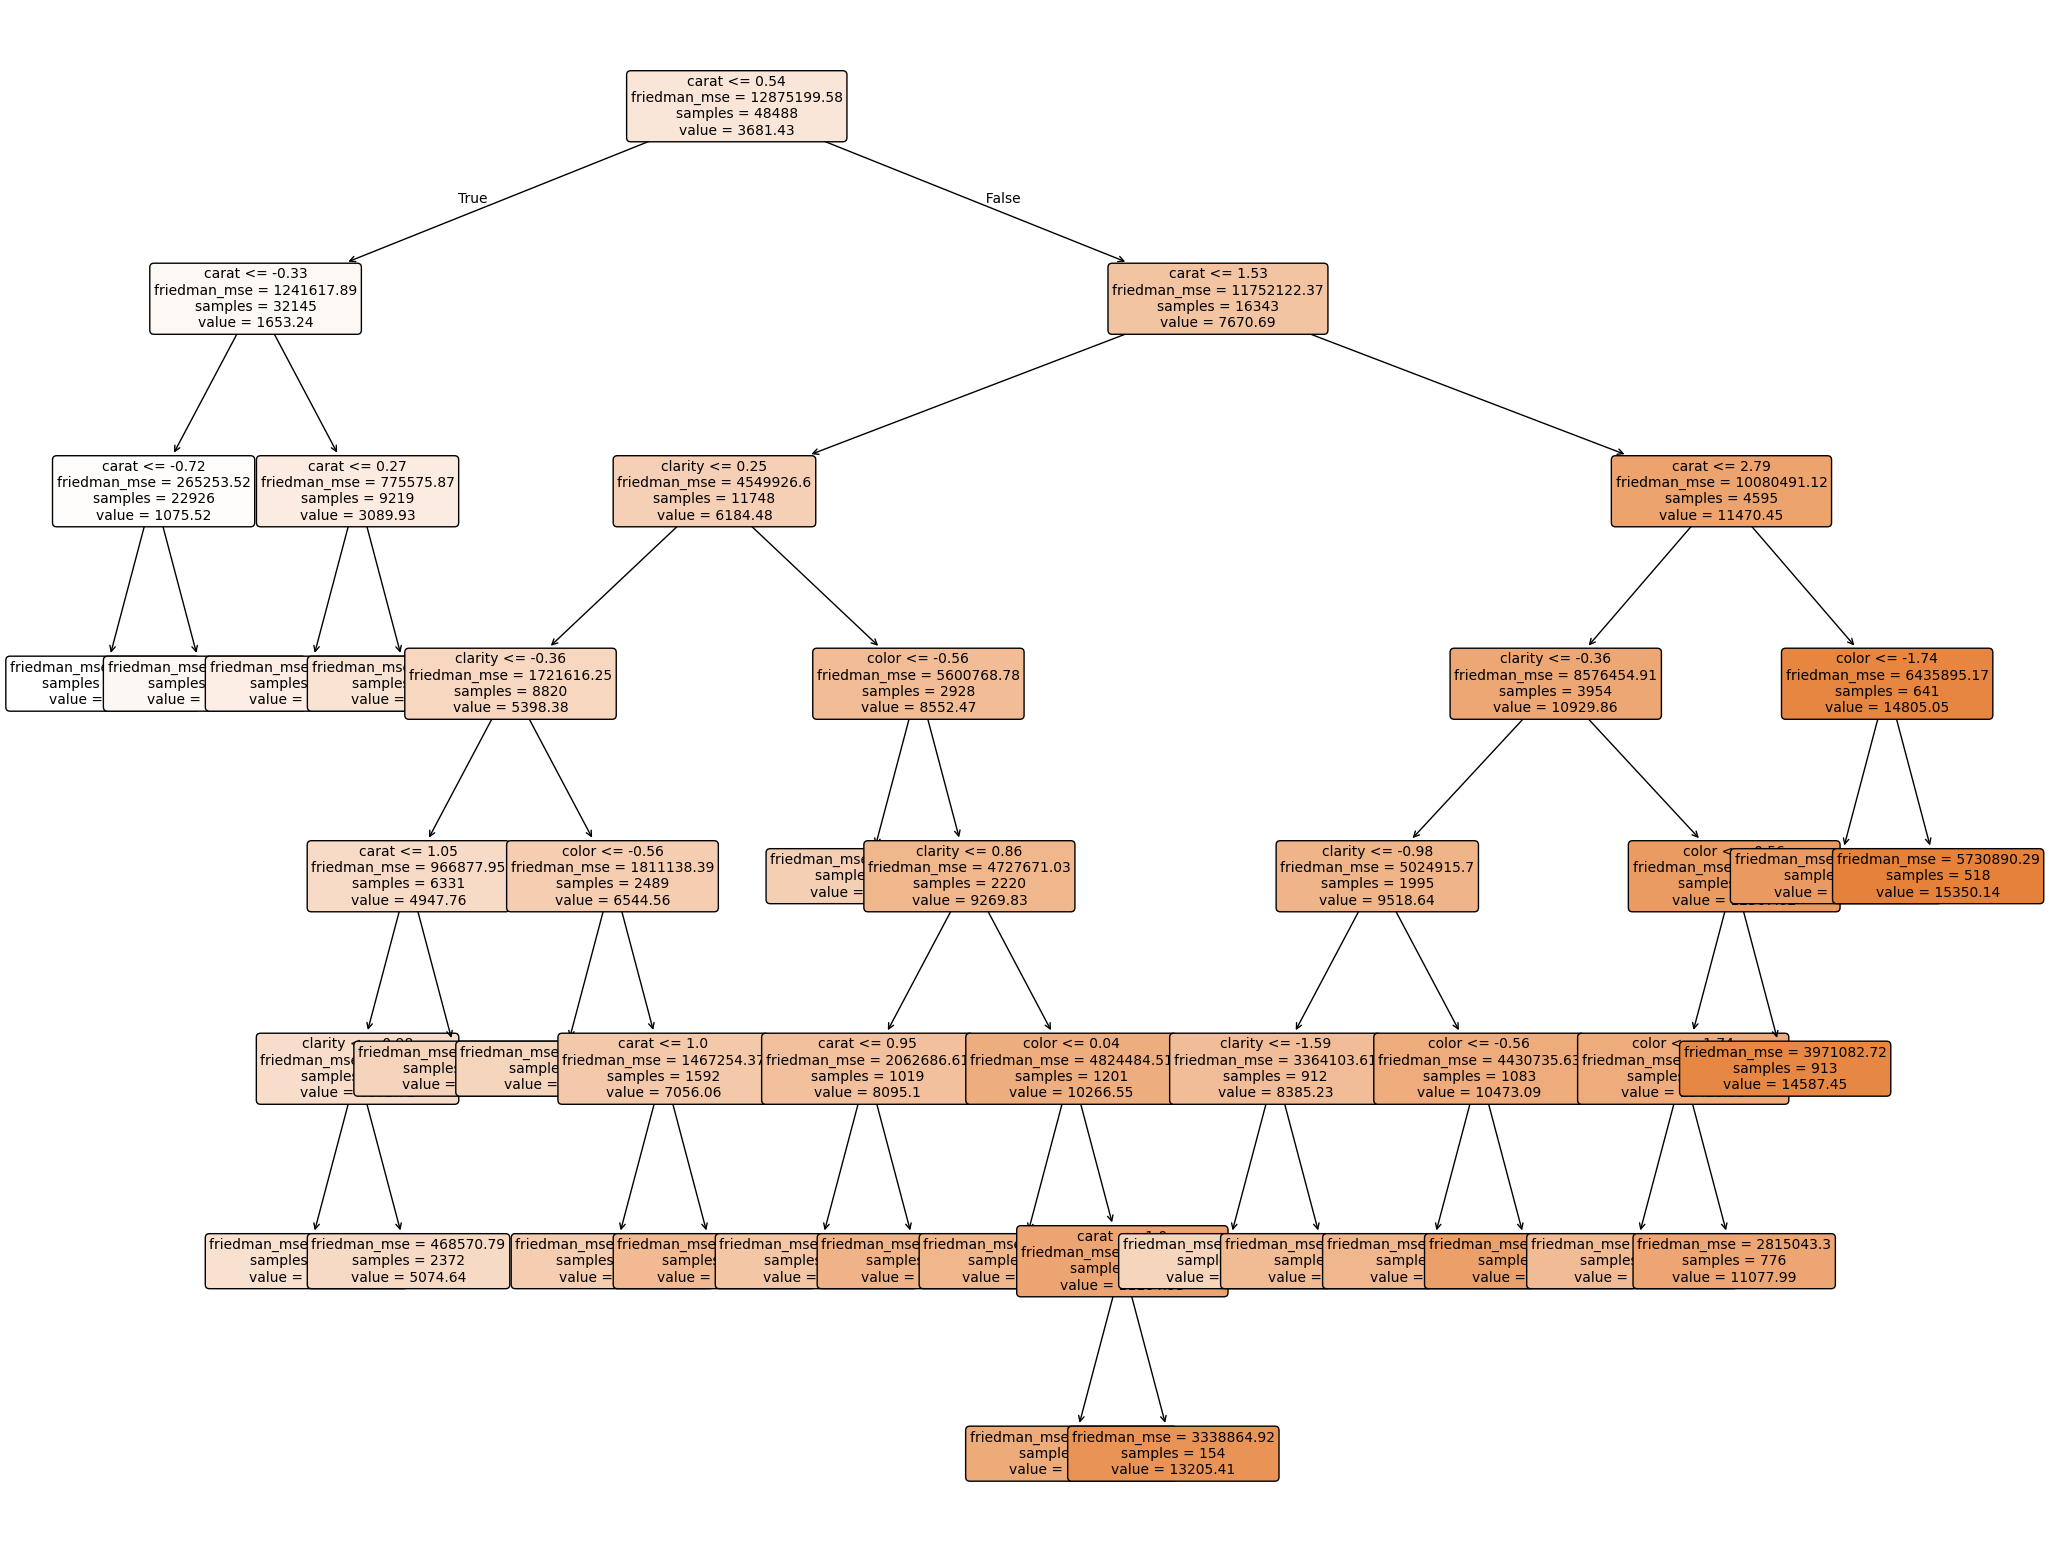

In [19]:
best_params = study.best_params

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

final_model = DecisionTreeRegressor(**best_params, random_state=81)
final_model.fit(x_scaled, y)

fig = plt.figure(figsize=(25, 20), facecolor='white')
ax = fig.add_subplot(111)

plot_tree(final_model, 
          feature_names=data.drop('price', axis=1).columns, 
          filled=True, 
          rounded=True, 
          precision=2, 
          fontsize=10,
          ax=ax)

plt.show()